# Meta Analysis

SEOYEON CHOI  
2025-10-05

[Reference](https://wikidocs.net/229908)

# 0. 정의

Meta analysis: 별도의 연구 결과를 통계적으로 결합하는 과정으로 여러
독립적인 연구 결과를 하나로 통합하는 작업

1.  문헌 검토
2.  데이터 시트 작성
3.  효과 크기 계산
4.  메타 분석 결과 해석

# 1. 문헌 검토

-   연구 질문 정의
-   키워드 식별
-   검색 전략 정의
-   수집된 논문에서 분석 결과 추출

# 2. 데이터 시트 작성

-   분석 유형
    -   여러 연구해서 결론이 내려진 분석 결과를 수식을 통한 계산 작업을
        거쳐 표준화된 값으로 변환
-   데이터 유형
    -   범주형 유형
        -   명목 척도
        -   순위 척도
    -   연속형 유형
        -   등간 척도
        -   비율 척도

# 3. 효과 크기

ttest,anova,correation analysis 등에서 제시된 다양한 연구결과로 아래를
계산

-   주의할 점은 표본이 작은 경우 효과 크기가 과대추정될 수 있으니 샘플
    수를 확인해야 한다는 것

-   효과 크기

    -   표준화된 평균차이
        -   Cohen
    -   두 집단의 비율
        -   Odds ratio
    -   두 변수 간의 상관관계
        -   Correlation

-   Cohen’s Effect size: $d = \frac{\bar{X} - \bar{X}}{S}$

    -   \<=0.2 작은 효과, 0.2~0.8 중간 효과, \>=0.8 큰 효과

연구 결과에서 효과 크기, 신뢰구간, 가중치 해석

-   가중치
    -   샘플 수가 달라서 효과 크기 계산에 영향을 줄 수 있어서 조정해줘야
        함
    -   se로
-   $J = (1-\frac{3}{4df-1})$
-   Hedges’ Effect Size = $g = d\times J$

이질성 검증

-   $I^2 = \frac{Q-df}{Q} \times 100$
    -   0% ~ 25% 이질성이 낮음
    -   25% ~ 75% 중간정도의 이질성이 있음
    -   75% ~ 100% 이질성이 높음
-   $I^2$가 50% 이상이고, 이질성 검증의 유의확률 p-value가 p\<0.1인 경우
    효과 크기의 이질성이 있는 것으로 판단하고 고정 효과 모델 대신 랜덤
    효과 모델 선택
    -   랜덤 효과 모델은 더 보수적인 신뢰구간 제공
-   고정 효과 모델 선택하려면 동일한 모딥단에서 추출한 표본의 경우에
    사용 가능.
    -   일반화 어려움
-   랜덤 표과 모델
    -   메타 분석은 다양한 연구를 포함하기 때문에 표본 집단이 다른
        경우가 많다.

출판 오류,평향 분석

-   연구 결과의 신뢰성과 타당성을 보장하기 위함

-   메타 분석이 실제 효과를 과대 또는 과소 추정할 수 있음

-   좌우 대칭으로 나오면 편향이 없는 것으로 보지만, 비대칭 분포를 가지면
    편향이 있는 것으로 봄

-   일반적으로 안전계수 값이 $5 \times N + 10$ 여기서 N은 메타분석
    논문수 보다 크면 대체로 안전하다고 판단

# 4. 실습

## 첫번째

-   Import

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from math import sqrt, log, exp

1.  예제 데이터
    -   a = treatment effect
    -   b = treatment non-events
    -   c = control events
    -   d = control non-events

In [8]:
df = pd.DataFrame({
    "study": ["Study A","Study B","Study C","Study D","Study E","Study F"],
    "a": [22, 18, 15, 40, 27, 12],
    "b": [78, 82, 75, 160,123, 68],
    "c": [30, 25, 24, 50, 35, 11],
    "d": [70, 75, 66, 150,115, 69],
})
df

1.  효과 크기 계산

In [9]:
def log_or_and_se(a,b,c,d, add0_5=True):
    if add0_5 and min(a,b,c,d) == 0:
        a, b, c, d = a+0.5, b+0.5, c+0.5, d+0.5
    logOR = log((a*d)/(b*c))
    SE = sqrt(1/a + 1/b + 1/c + 1/d)
    return logOR, SE

In [10]:
Z = 1.96  # 95% CI

In [11]:
df["logOR"], df["SE"] = zip(*df.apply(lambda r: log_or_and_se(r.a,r.b,r.c,r.d), axis=1))
df["logLCL"] = df["logOR"] - Z*df["SE"]
df["logUCL"] = df["logOR"] + Z*df["SE"]

In [12]:
# OR 스케일로 보기
df["OR"]    = np.exp(df["logOR"])
df["OR_LCL"]= np.exp(df["logLCL"])
df["OR_UCL"]= np.exp(df["logUCL"])

In [13]:
df.round(3)

1.  고정효과 메타분석

In [14]:
w_fixed = 1 / (df["SE"]**2)
theta_fixed = np.sum(w_fixed * df["logOR"]) / np.sum(w_fixed)      # 가중 평균
se_fixed = sqrt(1 / np.sum(w_fixed))
fixed_L = theta_fixed - Z*se_fixed
fixed_U = theta_fixed + Z*se_fixed

print("Fixed-effect (log scale):", theta_fixed, "±", se_fixed)
print("Fixed-effect (OR):", exp(theta_fixed), 
      "(95% CI", exp(fixed_L), "to", exp(fixed_U), ")")

Fixed-effect (log scale): -0.34053900893309863 ± 0.12983334833335455
Fixed-effect (OR): 0.7113867755772918 (95% CI 0.551555742161936 to 0.9175339966230908 )

-   pooled OR 통합오즈비 = 0.71
    -   1보다 작다는 건 치료가 더 좋은 효과
    -   치료군의 사건 발생 odds가 대조군 대비 약 29% 감소
-   95% CI = 0.55, 0.92
    -   95% CI가 1을 포함하지 않음
    -   따라서 통계적으로 유의한 차이 존재

1.  이질성

In [15]:
Q = np.sum(w_fixed * (df["logOR"] - theta_fixed)**2)
df_Q = len(df) - 1
I2 = max(0.0, (Q - df_Q) / Q) * 100 if Q > 0 else 0.0

print(f"Heterogeneity: Q={Q:.2f}, df={df_Q}, I²={I2:.1f}%")

Heterogeneity: Q=1.60, df=5, I²=0.0%

-   이질성은 1.60
-   $I^2$으로 보아 효과 크기 차이가 거의 없음.
-   따라서 모든 연구들이 일관된 방향을 보여줌
-   이질성이 낮으므로 고정효과 모델 결과와 랜덤 표과 모델 결과가 거의
    동일하게 나올 것으로 예상

1.  랜덤 효과

In [16]:
den = np.sum(w_fixed) - (np.sum(w_fixed**2) / np.sum(w_fixed))
tau2 = max(0.0, (Q - df_Q) / den)  # between-study variance (DL)

w_random = 1 / (df["SE"]**2 + tau2)
theta_random = np.sum(w_random * df["logOR"]) / np.sum(w_random)
se_random = sqrt(1 / np.sum(w_random))
random_L = theta_random - Z*se_random
random_U = theta_random + Z*se_random

print("Random-effects (log):", theta_random, "±", se_random, " | tau²=", tau2)
print("Random-effects (OR):", exp(theta_random), 
      "(95% CI", exp(random_L), "to", exp(random_U), ")")

Random-effects (log): -0.34053900893309863 ± 0.12983334833335455  | tau²= 0.0
Random-effects (OR): 0.7113867755772918 (95% CI 0.551555742161936 to 0.9175339966230908 )

-   $tau^2$ 값으로 보아 betwee-study variance가 거의 없음
-   따라서 pooled OR이 고정 효과 모델과 동일하게 계산된다.

1.  포레스트 플롯

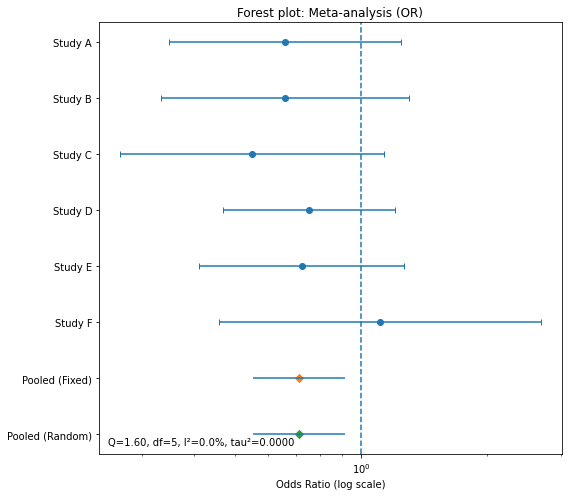

In [19]:
y = np.arange(len(df), 0, -1)

fig, ax = plt.subplots(figsize=(8,7))
ax.errorbar(df["OR"], y,
            xerr=[df["OR"]-df["OR_LCL"], df["OR_UCL"]-df["OR"]],
            fmt='o', capsize=3)

# 고정/랜덤 풀드 효과(다이아몬드 마커)
ax.plot(np.exp(theta_fixed), 0, marker='D')
ax.hlines(0, np.exp(fixed_L), np.exp(fixed_U))

ax.plot(np.exp(theta_random), -1, marker='D')
ax.hlines(-1, np.exp(random_L), np.exp(random_U))

ax.axvline(1.0, linestyle='--')
ax.set_xscale("log")
ax.set_xlabel("Odds Ratio (log scale)")
ax.set_yticks(list(y) + [0, -1])
ax.set_yticklabels(list(df["study"]) + ["Pooled (Fixed)", "Pooled (Random)"])
ax.set_title("Forest plot: Meta-analysis (OR)")
ax.text(0.02, 0.02, f"Q={Q:.2f}, df={df_Q}, I²={I2:.1f}%, tau²={tau2:.4f}",
        transform=ax.transAxes)
plt.tight_layout()
plt.show()

-   대부분의 연구 결과가 왼쪽에 위치, OR \<1
-   pooled fixed, pooled random이 1보다 왼쪽에 위치
-   전반적인 치료가 효과적임을 시각적으로 확인할 수 있음

## 두번째

-   import

In [46]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

-   데이터 연구의 효과 크기, 표준 오차

In [21]:
data = pd.DataFrame({
    'study': ['Study1', 'Study2', 'Study3', 'Study4', 'Study5'],
    'effect_size': [0.20, 0.35, 0.10, 0.50, 0.40],
    'se': [0.10, 0.15, 0.08, 0.12, 0.10]
})

In [22]:
data

-   고정 효과 가중치 계산

$w_i = \frac{1}{SE_i^2}$

In [23]:
data['weight_FE'] = 1 / data['se']**2

In [24]:
data['weight_FE']

0    100.000000
1     44.444444
2    156.250000
3     69.444444
4    100.000000
Name: weight_FE, dtype: float64

-   고정효과 모델의 통합 효과 추정

$\hat{\mu}_{FE} = \frac{\sum w_i y_i}{\sum w_i}$

-   ($y_i$): 각 연구의 효과크기
-   ($w_i$): 각 연구의 가중치

In [25]:
fixed_effect = np.sum(data['weight_FE'] * data['effect_size']) / np.sum(data['weight_FE'])

In [26]:
fixed_effect

0.2677991137370753

-   이질성 검정 Heterogeneity Test

Cochran’s Q

$Q = \sum w_i (y_i - \hat{\mu}_{FE})^2$

df = 연구 수 - 1

$Q \sim \chi^2_{df}$

In [27]:
data['Q_component'] = data['weight_FE'] * (data['effect_size'] - fixed_effect)**2
Q = np.sum(data['Q_component'])
df = len(data) - 1

In [30]:
data['Q_component']

0    0.459672
1    0.300310
2    4.399460
3    3.744254
4    1.747707
Name: Q_component, dtype: float64

In [29]:
Q

10.651403249630723

In [28]:
df

4

$\chi^2_{0.05} = 9.49$

-   H0 = 이질성이 없다, 모든 연구가 동일하다.
-   H1 = 이질성이 있다, 연구가 동일하지 않다.

10.65 \> 9.49, 따라서 귀무가설 기각, 이질성이 있다.

-   DerSimonian–Laird 추정량, 타우 값 구하기
    -   랜덤 효과 모형 추정하기 위해서

랜덤 효과 모형은 $y_i = \mu + u_i + \epsilon_i$같은 분포를 따르는 값으로
가정

-   ($u_i \sim N(0, \tau^2)$): 연구 간의 분산(이질성)

-   ($\epsilon_i \sim N(0, SE_i^2)$): 연구 내의 표본 오차

-   고정효과 모형의 가중치 : $\frac{1}{s^2}$

    -   이질성 고려 하지 않음

-   랜덤 효과 가중치 : $\frac{1}{s^2 + \tau^2}$

    -   이질성 고려는 연구 간 분산인 $\tau^2$으로 고려

$\tau^2 = \frac{Q - (k - 1)}{C}$, 타우가 음수면 0으로 처리

$C = \sum w_i - \frac{\sum w_i^2}{\sum w_i}$

In [31]:
C = np.sum(data['weight_FE']) - (np.sum(data['weight_FE']**2) / np.sum(data['weight_FE']))
tau_sq = max(0, (Q - df) / C)

In [32]:
C

361.20958476940757

In [33]:
tau_sq

0.018414249040143577

-   랜덤 효과 가중치

$y_i \sim N(\mu, SE_i^2 + \tau^2)$, 각 연구 효과의 분포, 연구내
오차+분산까지 함께 고려

$w_i^* = \frac{1}{SE_i^2 + \tau^2}$

In [34]:
data['weight_RE'] = 1 / (data['se']**2 + tau_sq)

In [35]:
data['weight_RE'] 

0    35.193610
1    24.441363
2    40.299426
3    30.474566
4    35.193610
Name: weight_RE, dtype: float64

-   랜덤 효과 모델의 통합 효과 추정

$\hat{\mu}_{RE} = \frac{\sum w_i^* y_i}{\sum w_i^*}$

$SE_{\hat{\mu}_{RE}} = \sqrt{\frac{1}{\sum w_i^*}}$

In [36]:
random_effect = np.sum(data['weight_RE'] * data['effect_size']) / np.sum(data['weight_RE'])
random_se = np.sqrt(1 / np.sum(data['weight_RE']))

In [37]:
random_effect

0.29551393503100565

In [38]:
random_se

0.07770812983895702

-   95% 신뢰구간

$CI = \hat{\mu}*{RE} \pm 1.96 \times SE*{\hat{\mu}_{RE}}$

In [39]:
ci_low = random_effect - 1.96 * random_se
ci_high = random_effect + 1.96 * random_se

In [40]:
ci_high;ci_low

0.1432060005466499

-   결과

In [42]:
print(f"Random-Effects Mean Effect Size: {random_effect:.3f}")
print(f"Between-Study Variance (tau²): {tau_sq:.4f}")
print(f"95% CI: [{ci_low:.3f}, {ci_high:.3f}]")

Random-Effects Mean Effect Size: 0.296
Between-Study Variance (tau²): 0.0184
95% CI: [0.143, 0.448]

-   연구 전체 효과는 0.296

-   타우값으로 보아 이질성은 존재하지만 크지 않음을 보임

-   신뢰구간이 0을 포함하지 않아 연구 효과가 유의함을 보임

-   forest plot

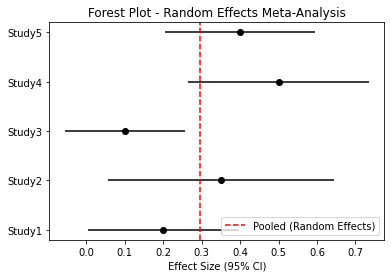

In [45]:
plt.errorbar(data['effect_size'], range(len(data)), xerr=data['se']*1.96, fmt='o', color='black')
plt.axvline(random_effect, color='red', linestyle='--', label='Pooled (Random Effects)')
plt.yticks(range(len(data)), data['study'])
plt.xlabel('Effect Size (95% CI)')
plt.title('Forest Plot - Random Effects Meta-Analysis')
plt.legend()
plt.show()

## 세번째_Fisher’s z 기반 상관계수 변환 분석

-   import

In [47]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

-   data

In [48]:
data = pd.DataFrame({
    'study': ['Fonda(2002)', 'Newman(2012)', 'Grant(2003)', 'Granger(2020)', 'Milland(2018)', 'Finch(2021)'],
    'r': [0.5, 0.5, 0.4, 0.2, 0.7, 0.45],
    'n': [40, 90, 25, 40, 60, 50]
})
data

-   Fisher’s z 변환
    -   정규성 확보하기 위해
    -   r의 분포가 비대칭이라서
-   $z_i = \tfrac{1}{2}\ln\frac{1+r_i}{1-r_i}$
-   $\mathrm{Var}(z_i) = \frac{1}{n_i-3}$
-   $SE_i = \sqrt{\frac{1}{n_i-3}}$

In [49]:
data['z'] = np.arctanh(data['r'])  # Fisher’s z
data['var_z'] = 1 / (data['n'] - 3)  # 분산(표준오차^2)
data['se_z'] = np.sqrt(data['var_z'])

In [50]:
data

-   고정효과 가중치
    -   모든 연구가 동일한 효과를 추정한다고 가정하는 고정효과
    -   각 연구의 신뢰성, 즉 정밀도는 분산의 역수로 가중치를 부여

$w_i^{FE} = \frac{1}{\mathrm{Var}(z_i)} = n_i - 3$

In [51]:
data['w_FE'] = 1 / data['var_z']

In [52]:
data

-   고정효과 통합 효과 추정치 계산

$\hat{z}_{FE} = \frac{\sum w_i^{FE} z_i}{\sum w_i^{FE}}$

In [53]:
z_FE = np.sum(data['w_FE'] * data['z']) / np.sum(data['w_FE'])

In [54]:
z_FE

0.5475692893176466

-   이질성 체크를 위한 q 통계량

-   $Q = \sum w_i^{FE}(z_i - \hat{z}_{FE})^2,\quad df = k-1$

-   $C = \sum w_i^{FE} - \frac{\sum (w_i^{FE})^2}{\sum w_i^{FE}}$

-   $\tau^2 = \max\left(0,\frac{Q - df}{C}\right)$

In [55]:
Q = np.sum(data['w_FE'] * (data['z'] - z_FE)**2)
df = len(data) - 1
C = np.sum(data['w_FE']) - (np.sum(data['w_FE']**2) / np.sum(data['w_FE']))
tau2 = max(0, (Q - df) / C)  # DerSimonian–Laird τ²

In [57]:
Q

10.750737304131887

In [58]:
df

5

In [59]:
C

230.38327526132406

In [60]:
tau2

0.024961609290469623

이질성이 낮음, 타우로 보아 이질성이 존재하긴 하는 것으로 보임

-   랜덤 효과 가중치
    -   연구 간 효과가 다름을 허용,
    -   총 분산을 연구 내 분산과 연구 간 분산의 합으로 사용

$w_i^{RE} = \frac{1}{\mathrm{Var}(z_i) + \tau^2}$

In [61]:
data['w_RE'] = 1 / (data['var_z'] + tau2)

In [62]:
data

-   랜덤 효과 모델의 통합 효과 계산

-   $\hat{z}*{RE} = \frac{\sum w_i^{RE} z_i}{\sum w_i^{RE}}$

-   $SE(\hat{z}*{RE}) = \sqrt{\frac{1}{\sum w_i^{RE}}}$

In [63]:
z_RE = np.sum(data['w_RE'] * data['z']) / np.sum(data['w_RE'])
se_RE = np.sqrt(1 / np.sum(data['w_RE']))

In [64]:
z_RE

0.5304102438741388

In [65]:
se_RE

0.08935156116618687

-   95% ci

$CI_z = \hat{z}*{RE} \pm 1.96\times SE*{\hat{z}_{RE}}$

In [66]:
ci_low_z = z_RE - 1.96 * se_RE
ci_high_z = z_RE + 1.96 * se_RE

In [67]:
ci_high_z

0.7055393037598651

In [68]:
ci_low_z

0.3552811839884126

-   상관계수 역변환
    -   메타분석 결과를 상관계수로 해석하기 위해서
    -   계산은 z로 하고 해석은 r로 함

$r = \tanh(z) = \frac{e^{2z}-1}{e^{2z}+1}$

In [69]:
r_RE = np.tanh(z_RE)
r_low = np.tanh(ci_low_z)
r_high = np.tanh(ci_high_z)

In [70]:
r_RE

0.4856946207056017

In [71]:
r_low

0.34105082132846415

In [72]:
r_high

0.6078720252330513

-   결과 해석

In [73]:
print("Random-Effects Meta-Analysis (DerSimonian–Laird)")
print(f"Between-study variance (tau²): {tau2:.5f}")
print(f"Pooled Fisher’s z: {z_RE:.4f} (SE = {se_RE:.4f})")
print(f"Pooled correlation (r): {r_RE:.3f}")
print(f"95% CI for r: [{r_low:.3f}, {r_high:.3f}]")

Random-Effects Meta-Analysis (DerSimonian–Laird)
Between-study variance (tau²): 0.02496
Pooled Fisher’s z: 0.5304 (SE = 0.0894)
Pooled correlation (r): 0.486
95% CI for r: [0.341, 0.608]

-   연구 전반의 상관계수 r은 통계적으로 유의함
-   이질성 타우도 중등도 수준으로 존재함
-   중간 정도 양의 상관관계 r로 해석 가능함

$z_i \pm 1.96SE_i \Rightarrow r_i^\text{low/high} = \tanh(z_i^\text{low/high})$

-   forest plot에 사용하기 위해서

In [74]:
data['z_low'] = data['z'] - 1.96 * data['se_z']
data['z_high'] = data['z'] + 1.96 * data['se_z']
data['r_low'] = np.tanh(data['z_low'])
data['r_high'] = np.tanh(data['z_high'])

In [75]:
data

-   연구 효과의 크기는 검정색 점으로 표시
-   가로선은 각 연구의 95% ci
-   세로 점선은 전체 통합 상관계수 값 r_RE

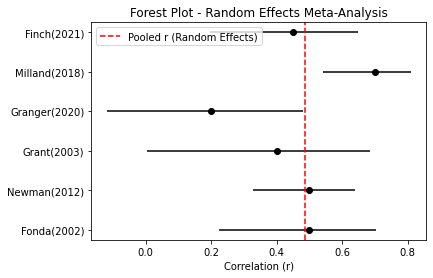

In [76]:
plt.errorbar(data['r'], range(len(data)), 
             xerr=[data['r'] - data['r_low'], data['r_high'] - data['r']], 
             fmt='o', color='black')
plt.axvline(r_RE, color='red', linestyle='--', label='Pooled r (Random Effects)')
plt.yticks(range(len(data)), data['study'])
plt.xlabel('Correlation (r)')
plt.title('Forest Plot - Random Effects Meta-Analysis')
plt.legend()
plt.show()